In [1]:
%load_ext cuml.accel
%run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_updated.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

/opt/py_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
workspace = "/workspace/alvin/SAR_ML"
# workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [5]:
sorted(os.listdir(clutter_dir))[0]

'HB06158'

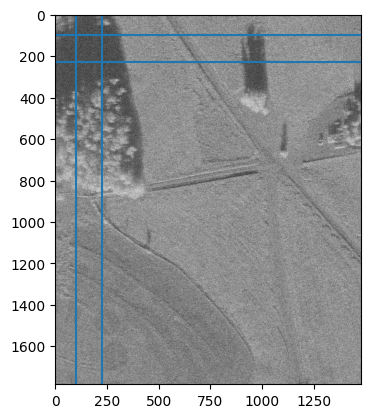

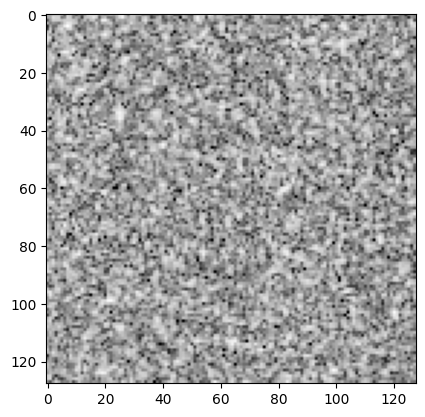

In [18]:
xk = 100
yk = 100

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, sorted(os.listdir(clutter_dir))[0]))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()